In [9]:
from collections import Counter
from io import open
from torch import optim

import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random
import re
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import unicodedata

%matplotlib inline

In [10]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

device

'cpu'

In [11]:
SOS_token = 0
EOS_token = 1
MAX_LENGTH = 12
MAX_PAIRS = 20000
TEST_RATIO = 0.1
VAL_RATIO = 0.1
teacher_forcing_ratio = 0.5

In [12]:
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: 'SOS', 1: 'EOS'}
        self.n_words = 2

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [13]:
def unicodeToAsciiKeepCyrillic(s):
    s = unicodedata.normalize('NFKC', s)
    return s


def normalizeString(s):
    s = unicodeToAsciiKeepCyrillic(s.lower().strip())
    s = s.replace('ё', 'е')
    s = re.sub(r'([.!?])', r' \1', s)
    s = re.sub(r'[^a-zа-я.!?]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

In [14]:
def readLangs(lang1, lang2, reverse=False):
    print('Reading')

    lines = open('rus.txt', encoding='utf-8').read().strip().split('\n')

    pairs = []
    for line in lines:
        parts = line.split('\t')
        if len(parts) < 2:
            continue

        eng = normalizeString(parts[0])
        rus = normalizeString(parts[1])

        if eng and rus:
            pairs.append([eng, rus])

    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

In [15]:
def filterPair(p):
    return (
            len(p[0].split(' ')) < MAX_LENGTH and
            len(p[1].split(' ')) < MAX_LENGTH
    )


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [16]:
def prepareData(lang1, lang2, reverse=False, max_pairs=None):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print(f'Read {len(pairs)} sentence pairs')

    pairs = filterPairs(pairs)
    print(f'Trimmed to {len(pairs)} sentence pairs')

    random.shuffle(pairs)
    if max_pairs is not None:
        pairs = pairs[:max_pairs]

    print('Counting words...')
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])

    print('Counted words:')
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)

    return input_lang, output_lang, pairs


input_lang, output_lang, pairs = prepareData('eng', 'rus', reverse=False, max_pairs=MAX_PAIRS)
print(random.choice(pairs))

n_total = len(pairs)
n_test = int(n_total * TEST_RATIO)
n_val = int(n_total * VAL_RATIO)
n_train = n_total - n_val - n_test

train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train + n_val]
test_pairs = pairs[n_train + n_val:]

print(f'train: {len(train_pairs)}, val: {len(val_pairs)}, test: {len(test_pairs)}')

Reading
Read 145239 sentence pairs
Trimmed to 145238 sentence pairs
Counting words...
Counted words:
eng 4292
rus 9862
['tom will leave soon .', 'том скоро уйдет .']
train: 16000, val: 2000, test: 2000


In [17]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ') if word in lang.word2index]


def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)


def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return input_tensor, target_tensor

In [18]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, rnn_type='GRU', num_layers=1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn_type = rnn_type.upper()

        self.embedding = nn.Embedding(input_size, hidden_size)

        if self.rnn_type == 'GRU':
            self.rnn = nn.GRU(hidden_size, hidden_size, num_layers=num_layers)
        elif self.rnn_type == 'LSTM':
            self.rnn = nn.LSTM(hidden_size, hidden_size, num_layers=num_layers)
        else:
            raise ValueError('rnn_type must be GRU or LSTM')

    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output = embedded
        output, hidden = self.rnn(output, hidden)
        return output, hidden

    def initHidden(self):
        if self.rnn_type == 'GRU':
            return torch.zeros(self.num_layers, 1, self.hidden_size, device=device)
        else:
            h0 = torch.zeros(self.num_layers, 1, self.hidden_size, device=device)
            c0 = torch.zeros(self.num_layers, 1, self.hidden_size, device=device)
            return (h0, c0)

In [19]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, rnn_type='GRU', num_layers=1):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn_type = rnn_type.upper()

        self.embedding = nn.Embedding(output_size, hidden_size)

        if self.rnn_type == 'GRU':
            self.rnn = nn.GRU(hidden_size, hidden_size, num_layers=num_layers)
        elif self.rnn_type == 'LSTM':
            self.rnn = nn.LSTM(hidden_size, hidden_size, num_layers=num_layers)
        else:
            raise ValueError('rnn_type must be GRU or LSTM')

        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        output = self.embedding(input).view(1, 1, -1)
        output = F.relu(output)
        output, hidden = self.rnn(output, hidden)
        output = self.softmax(self.out(output[0]))
        return output, hidden

    def initHidden(self):
        if self.rnn_type == 'GRU':
            return torch.zeros(self.num_layers, 1, self.hidden_size, device=device)
        else:
            h0 = torch.zeros(self.num_layers, 1, self.hidden_size, device=device)
            c0 = torch.zeros(self.num_layers, 1, self.hidden_size, device=device)
            return (h0, c0)

In [20]:
def train_step(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    loss = 0

    for ei in range(input_length):
        _, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden

    use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

    if use_teacher_forcing:
        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di]
    else:
        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach().view(1, 1)

            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length

In [21]:
def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return f'{m}m {int(s)}s'


def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / percent
    rs = es - s
    return f'{asMinutes(s)} (- {asMinutes(rs)})'

In [22]:
def showPlot(points, title='loss'):
    plt.figure()
    fig, ax = plt.subplots()
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)
    plt.title(title)
    plt.show()


def trainIters(encoder, decoder, train_pairs, n_iters,
               print_every=1000, plot_every=1000, learning_rate=0.01):
    start = time.time()
    plot_losses = []
    print_loss_total = 0
    plot_loss_total = 0

    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)

    training_pairs = [tensorsFromPair(random.choice(train_pairs)) for _ in range(n_iters)]
    criterion = nn.NLLLoss()

    for iteration in range(1, n_iters + 1):
        input_tensor, target_tensor = training_pairs[iteration - 1]

        loss = train_step(
            input_tensor, target_tensor,
            encoder, decoder,
            encoder_optimizer, decoder_optimizer,
            criterion
        )

        print_loss_total += loss
        plot_loss_total += loss

        if iteration % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print(
                f'{timeSince(start, iteration / n_iters)} ({iteration} {iteration / n_iters * 100:.0f}%) {print_loss_avg:.4f}')

        if iteration % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses, title='training loss')

In [23]:
def evaluate(encoder, decoder, sentence, max_length=MAX_LENGTH):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)
        input_length = input_tensor.size(0)
        encoder_hidden = encoder.initHidden()

        for ei in range(input_length):
            _, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        decoded_words = []

        for _ in range(max_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.data.topk(1)

            if topi.item() == EOS_token:
                break
            else:
                decoded_words.append(output_lang.index2word[topi.item()])

            decoder_input = topi.squeeze().detach().view(1, 1)

        return decoded_words


def evaluateSentence(encoder, decoder, sentence):
    return ' '.join(evaluate(encoder, decoder, sentence))


def evaluateRandomly(encoder, decoder, pairs_subset, n=10):
    for _ in range(n):
        pair = random.choice(pairs_subset)
        print('>', pair[0])
        print('=', pair[1])
        print('<', evaluateSentence(encoder, decoder, pair[0]))
        print('')

In [24]:
def ngrams(tokens, n):
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]


def simple_bleu(reference_tokens, candidate_tokens, max_n=2):
    if len(candidate_tokens) == 0:
        return 0.0

    precisions = []
    for n in range(1, max_n + 1):
        ref_ngrams = Counter(ngrams(reference_tokens, n))
        cand_ngrams = Counter(ngrams(candidate_tokens, n))

        overlap = sum(min(count, ref_ngrams[gram]) for gram, count in cand_ngrams.items())
        total = sum(cand_ngrams.values())

        precision = (overlap + 1) / (total + 1)
        precisions.append(precision)

    geo_mean = 1.0
    for p in precisions:
        geo_mean *= p
    geo_mean = geo_mean ** (1 / max_n)

    ref_len = len(reference_tokens)
    cand_len = len(candidate_tokens)

    if cand_len > ref_len:
        bp = 1.0
    else:
        bp = math.exp(1 - ref_len / max(cand_len, 1))

    return bp * geo_mean


def evaluate_metrics(encoder, decoder, pairs_subset, max_examples=None):
    total_exact = 0
    total_token_acc = 0.0
    total_bleu = 0.0
    total = 0

    examples = []

    eval_pairs = pairs_subset if max_examples is None else pairs_subset[:max_examples]

    for src, tgt in eval_pairs:
        pred = evaluateSentence(encoder, decoder, src)

        ref_tokens = tgt.split()
        pred_tokens = pred.split()

        exact = int(pred.strip() == tgt.strip())

        matched = sum(1 for a, b in zip(ref_tokens, pred_tokens) if a == b)
        token_acc = matched / max(len(ref_tokens), 1)

        bleu = simple_bleu(ref_tokens, pred_tokens, max_n=2)

        total_exact += exact
        total_token_acc += token_acc
        total_bleu += bleu
        total += 1

        if len(examples) < 5:
            examples.append((src, tgt, pred))

    return {
        'exact_match': total_exact / total,
        'token_accuracy': total_token_acc / total,
        'bleu2': total_bleu / total,
        'examples': examples
    }

In [25]:
def run_experiment(name, rnn_type='GRU', num_layers=1,
                   hidden_size=256, n_iters=15000, learning_rate=0.01):
    print('=' * 80)
    print(f'Experiment: {name}')
    print(f'rnn_type={rnn_type}, num_layers={num_layers}, hidden_size={hidden_size}')

    encoder = EncoderRNN(
        input_size=input_lang.n_words,
        hidden_size=hidden_size,
        rnn_type=rnn_type,
        num_layers=num_layers
    ).to(device)

    decoder = DecoderRNN(
        hidden_size=hidden_size,
        output_size=output_lang.n_words,
        rnn_type=rnn_type,
        num_layers=num_layers
    ).to(device)

    trainIters(
        encoder, decoder,
        train_pairs=train_pairs,
        n_iters=n_iters,
        print_every=3000,
        plot_every=3000,
        learning_rate=learning_rate
    )

    print('\nValidation examples:')
    evaluateRandomly(encoder, decoder, val_pairs, n=5)

    val_metrics = evaluate_metrics(encoder, decoder, val_pairs, max_examples=500)
    test_metrics = evaluate_metrics(encoder, decoder, test_pairs, max_examples=500)

    print('Validation metrics:')
    print(val_metrics['exact_match'], val_metrics['token_accuracy'], val_metrics['bleu2'])

    print('Test metrics:')
    print(test_metrics['exact_match'], test_metrics['token_accuracy'], test_metrics['bleu2'])

    return {
        'name': name,
        'encoder': encoder,
        'decoder': decoder,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics
    }

Experiment: Baseline GRU 1 layer
rnn_type=GRU, num_layers=1, hidden_size=256
3m 57s (- 15m 48s) (3000 20%) 4.7028
7m 54s (- 11m 52s) (6000 40%) 4.2085
11m 55s (- 7m 56s) (9000 60%) 3.9190
16m 6s (- 4m 1s) (12000 80%) 3.7176
20m 18s (- 0m 0s) (15000 100%) 3.5342


<Figure size 640x480 with 0 Axes>

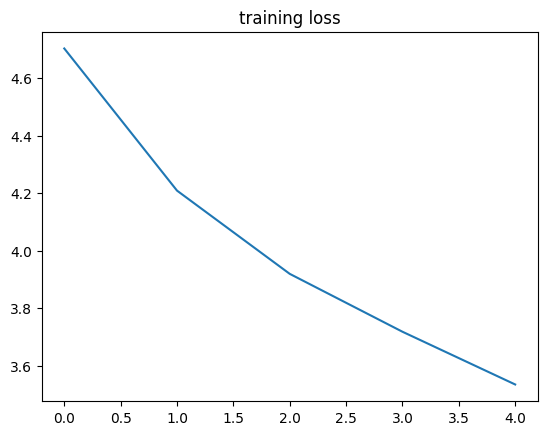


Validation examples:
> tom didn t have a car .
= у тома не было машины .
< у тома нет нет .

> who kissed you ?
= кто тебя поцеловал ?
< кто тебя кто ?

> i can t get rid of it .
= я не могу от этого избавиться .
< я не могу это это . .

> are you the doctor ?
= вы тот доктор ?
< вы ? ?

> do you like tom ?
= тебе том нравится ?
< ты нравится том ?

Validation metrics:
0.0 0.37992777777777775 0.37081556265726484
Test metrics:
0.0 0.36703095238095246 0.3613645622850349
Experiment: GRU 2 layers
rnn_type=GRU, num_layers=2, hidden_size=256
4m 28s (- 17m 53s) (3000 20%) 4.7098
9m 21s (- 14m 2s) (6000 40%) 4.2343
13m 48s (- 9m 12s) (9000 60%) 3.9846
18m 17s (- 4m 34s) (12000 80%) 3.7806
22m 43s (- 0m 0s) (15000 100%) 3.5801


<Figure size 640x480 with 0 Axes>

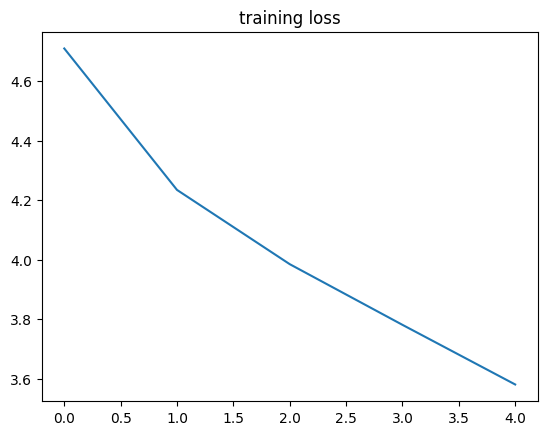


Validation examples:
> love conquers all .
= любовь побеждает все .
< мы были . .

> this apple is rotten .
= это яблоко сгнило .
< это очень .

> tom is my stepbrother .
= том мой сводный брат .
< том мой в .

> do you trust her ?
= ты ей доверяешь ?
< ты можешь ? ?

> tom only eats fruit .
= том ест одни фрукты .
< том не мэри .

Validation metrics:
0.002 0.35279126984126985 0.37650566616497644
Test metrics:
0.0 0.3323095238095242 0.37134027455412033
Experiment: LSTM 1 layer
rnn_type=LSTM, num_layers=1, hidden_size=256
5m 11s (- 20m 46s) (3000 20%) 4.7850
10m 29s (- 15m 44s) (6000 40%) 4.3627
15m 54s (- 10m 36s) (9000 60%) 4.1200
21m 16s (- 5m 19s) (12000 80%) 3.8764
26m 41s (- 0m 0s) (15000 100%) 3.7611


<Figure size 640x480 with 0 Axes>

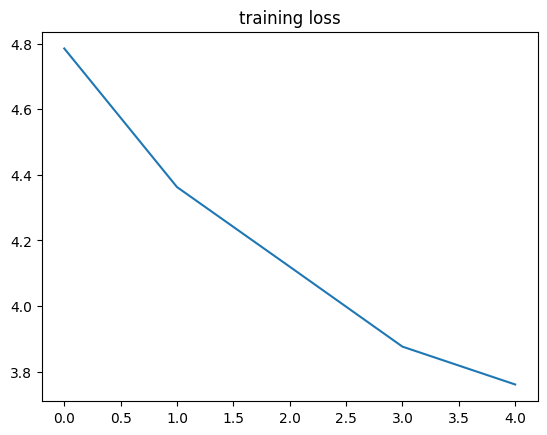


Validation examples:
> how big is it ?
= насколько он большой ?
< это это ? ?

> i m flat broke .
= я на мели .
< я меня . .

> someone s singing .
= кто то поет .
< он . .

> your bath is ready .
= ваша ванна готова .
< у меня .

> i don t know the bride .
= я не знаком с невестой .
< я не не не . .

Validation metrics:
0.0 0.3709944444444444 0.3614670589961424
Test metrics:
0.002 0.35466904761904755 0.35564704492427024
Experiment: LSTM 2 layers
rnn_type=LSTM, num_layers=2, hidden_size=256
6m 41s (- 26m 45s) (3000 20%) 4.8867
13m 45s (- 20m 38s) (6000 40%) 4.4128
20m 48s (- 13m 52s) (9000 60%) 4.2150
27m 54s (- 6m 58s) (12000 80%) 4.0380
34m 55s (- 0m 0s) (15000 100%) 3.9289


<Figure size 640x480 with 0 Axes>

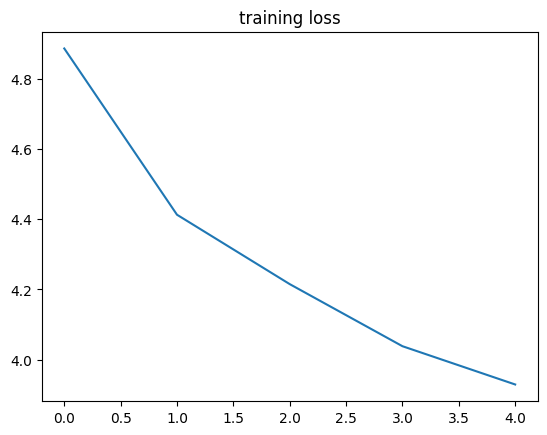


Validation examples:
> do you have any coffee ?
= у тебя есть кофе ?
< у у есть есть ?

> tom wants to drive .
= том хочет сесть за руль .
< том был . .

> it s gorgeous .
= это великолепно .
< это . .

> accidents will happen .
= будут аварии .
< у на . .

> how may i help you ?
= чем я могу тебе помочь ?
< что я я я ? ?

Validation metrics:
0.0 0.3575023809523811 0.3418224518129773
Test metrics:
0.0 0.3379714285714286 0.3336219380382001


In [26]:
experiments = [
    {
        'name': 'Baseline GRU 1 layer',
        'rnn_type': 'GRU',
        'num_layers': 1
    },
    {
        'name': 'GRU 2 layers',
        'rnn_type': 'GRU',
        'num_layers': 2
    },
    {
        'name': 'LSTM 1 layer',
        'rnn_type': 'LSTM',
        'num_layers': 1
    },
    {
        'name': 'LSTM 2 layers',
        'rnn_type': 'LSTM',
        'num_layers': 2
    }
]

results = []

for config in experiments:
    result = run_experiment(
        name=config['name'],
        rnn_type=config['rnn_type'],
        num_layers=config['num_layers'],
        hidden_size=256,
        n_iters=15000,
        learning_rate=0.01
    )

    results.append(result)